In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier


In [2]:
RANDOM_STATE = 42

features = pd.read_csv("../data/features.txt", sep=r"\s+", header=None, names=["index", "feature_name"])

X_train = pd.read_csv("../data/train/X_train.txt", sep=r"\s+", header=None)
y_train = pd.read_csv("../data/train/y_train.txt", sep=r"\s+", header=None, names=["activity"])
subjects_train = pd.read_csv("../data/train/subject_train.txt", sep=r"\s+", header=None, names=["subject"])

X_test = pd.read_csv("../data/test/X_test.txt", sep=r"\s+", header=None)
y_test = pd.read_csv("../data/test/y_test.txt", sep=r"\s+", header=None, names=["activity"])
subjects_test = pd.read_csv("../data/test/subject_test.txt", sep=r"\s+", header=None, names=["subject"])

activity_labels = pd.read_csv("../data/activity_labels.txt", sep=r"\s+", header=None, names=["index", "activity_name"])

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (7352, 561) | X_test: (2947, 561)


## Model ladder (simple → more complex)

This notebook uses the **UCI HAR** split: fixed train/test windows with **561 engineered features** and **6 activities**. The first training cell uses **scaled 561-D** features. A later section fits **PCA** on the scaled training data (`n_components=0.95` variance), transforms train/test, and reruns the same models so you can see whether full features or PCA scores work better.

| Order | Model | Why try it |
|------|--------|------------|
| 1 | **Majority class** | Sanity baseline |
| 2 | **Gaussian Naive Bayes** | Very fast, independence assumption; weak on correlated sensor features but a classic first step |
| 3a | **Logistic regression (`lbfgs`)** | Multinomial LR; quasi-Newton, often fast and stable |
| 3b | **Logistic regression (`newton-cg`)** | Same model class; Newton conjugate-gradient optimizer for comparison |
| 4 | **k-NN** | Nonparametric, local decision boundaries; needs scaling (done here) |
| 5 | **Decision tree** | Interpretable nonlinear splits; prone to overfit without tuning |
| 6 | **Random forest** | Robust tabular default; handles interactions and feature scales well |
| 7 | **HistGradientBoosting** | Modern sklearn boosting; often among the best **tabular** sklearn models |
| 8 | **SVM RBF** | Classic nonlinear kernel method for HAR; can be slower on larger \(n\) |
| 9 | **MLP** | Small neural net on feature vectors; tests whether extra nonlinearity helps over linear / tree models |

**Later experiments:** **XGBoost / LightGBM / CatBoost**; tune PCA cutoff or fixed `n_components`; or **raw 128-step inertial signals** (1D CNN, TCN, LSTM) from `Inertial Signals/`.

,representation,model,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,Scaled full (561d),3b Logistic regression (newton-cg),0.955548,0.958363,0.954286,0.955420
1,Scaled full (561d),3a Logistic regression (lbfgs),0.954869,0.957717,0.953495,0.954669
2,Scaled full (561d),8 SVM (RBF),0.952155,0.952837,0.950778,0.951479
3,Scaled full (561d),"9 MLP (100, 50)",0.947743,0.951021,0.946382,0.947722
4,Scaled full (561d),7 HistGradientBoosting,0.934849,0.937273,0.933180,0.934272
5,Scaled full (561d),6 Random forest,0.929759,0.930742,0.926817,0.927979
6,Scaled full (561d),4 k-NN (k=5),0.880217,0.889699,0.874631,0.876608
7,Scaled full (561d),5 Decision tree,0.862572,0.862767,0.859023,0.859807
8,Scaled full (561d),2 Gaussian NB,0.770275,0.792466,0.769066,0.767235
9,Scaled full (561d),1 Majority (baseline),0.182219,0.030370,0.166667,0.051378


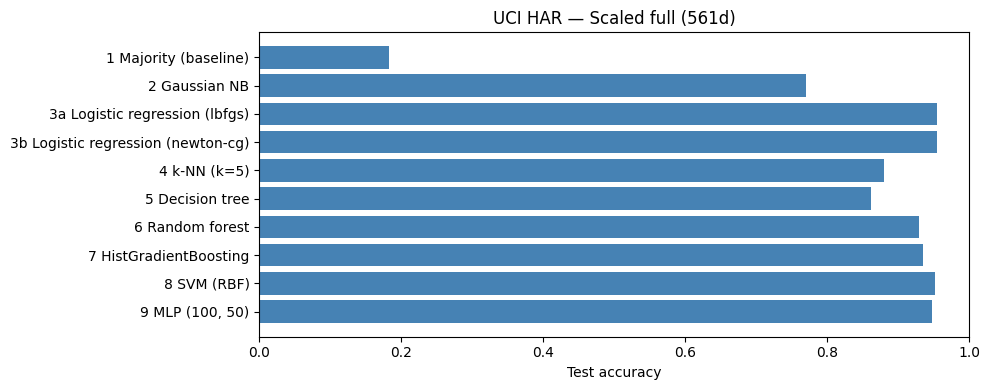

Best by test accuracy: 3b Logistic regression (newton-cg)

                    precision    recall  f1-score   support

           WALKING      0.944     0.994     0.969       496
  WALKING_UPSTAIRS      0.959     0.951     0.955       471
WALKING_DOWNSTAIRS      0.990     0.940     0.965       420
           SITTING      0.968     0.876     0.920       491
          STANDING      0.890     0.972     0.929       532
            LAYING      0.998     0.993     0.995       537

          accuracy                          0.956      2947
         macro avg      0.958     0.954     0.955      2947
      weighted avg      0.957     0.956     0.955      2947



In [3]:
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train["activity"].to_numpy())
y_test_enc = le.transform(y_test["activity"].to_numpy())
target_names = (
    activity_labels.set_index("index").loc[le.classes_, "activity_name"].astype(str).tolist()
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Ordered from simplest to more complex (see markdown above).
MODELS = {
    "1 Majority (baseline)": DummyClassifier(strategy="most_frequent"),
    "2 Gaussian NB": GaussianNB(),
    "3a Logistic regression (lbfgs)": LogisticRegression(
        max_iter=2000, solver="lbfgs", random_state=RANDOM_STATE
    ),
    "3b Logistic regression (newton-cg)": LogisticRegression(
        max_iter=2000, solver="newton-cg", random_state=RANDOM_STATE
    ),
    "4 k-NN (k=5)": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "5 Decision tree": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "6 Random forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "7 HistGradientBoosting": HistGradientBoostingClassifier(
        max_iter=200, random_state=RANDOM_STATE
    ),
    "8 SVM (RBF)": SVC(kernel="rbf", gamma="scale", random_state=RANDOM_STATE),
    "9 MLP (100, 50)": MLPClassifier(
        hidden_layer_sizes=(100, 50), max_iter=500, random_state=RANDOM_STATE
    ),
}


def run_all_models(Xtr, Xte, representation: str):
    rows, fitted = [], {}
    for name, template in MODELS.items():
        clf = clone(template)
        clf.fit(Xtr, y_train_enc)
        pred = clf.predict(Xte)
        rows.append(
            {
                "representation": representation,
                "model": name,
                "test_accuracy": accuracy_score(y_test_enc, pred),
                "test_macro_precision": precision_score(
                    y_test_enc, pred, average="macro", zero_division=0
                ),
                "test_macro_recall": recall_score(
                    y_test_enc, pred, average="macro", zero_division=0
                ),
                "test_macro_f1": f1_score(
                    y_test_enc, pred, average="macro", zero_division=0
                ),
            }
        )
        fitted[name] = clf
    return pd.DataFrame(rows), fitted


REP_FULL = "Scaled full (561d)"
results_full, fitted_full = run_all_models(X_train_s, X_test_s, REP_FULL)
display(results_full.sort_values("test_accuracy", ascending=False).reset_index(drop=True))

order = list(MODELS.keys())
acc = results_full.set_index("model")["test_accuracy"].reindex(order)
fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(range(len(order)), acc.values, color="steelblue")
ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_xlabel("Test accuracy")
ax.set_title(f"UCI HAR — {REP_FULL}")
ax.set_xlim(0, 1)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

best_name = results_full.sort_values("test_accuracy", ascending=False).iloc[0]["model"]
print(f"Best by test accuracy: {best_name}\n")
best_pred = fitted_full[best_name].predict(X_test_s)
print(classification_report(y_test_enc, best_pred, target_names=target_names, digits=3))


## PCA vs full features

**PCA** is fit on **scaled training data only** (`X_train_s`), then applied to train and test. We keep enough components to explain **95%** of the training variance, then rerun the **same model ladder** as above.

Compare the tables and bar chart to decide whether **561-D scaled features** or **PCA scores** work better for your models (linear models often like PCA; tree ensembles may prefer the original axes).


PCA (fit on train only): 102 components explain 0.9508 of train variance (from 561 scaled features).



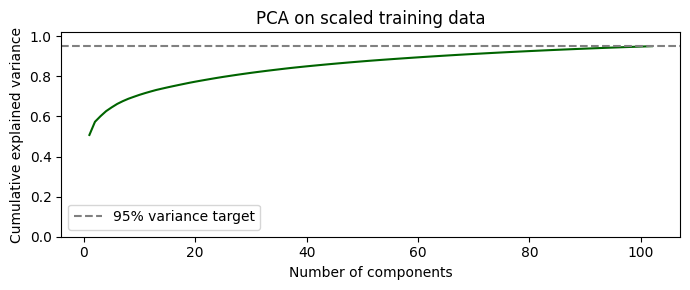

,representation,model,test_accuracy,test_macro_precision,test_macro_recall,test_macro_f1
0,"PCA (102d, 95% var)",8 SVM (RBF),0.937903,0.938822,0.935573,0.936558
1,"PCA (102d, 95% var)","9 MLP (100, 50)",0.934170,0.935343,0.931769,0.932822
2,"PCA (102d, 95% var)",3b Logistic regression (newton-cg),0.931795,0.932004,0.929620,0.930321
3,"PCA (102d, 95% var)",3a Logistic regression (lbfgs),0.930777,0.931005,0.928724,0.929411
4,"PCA (102d, 95% var)",7 HistGradientBoosting,0.918901,0.922945,0.914785,0.916290
5,"PCA (102d, 95% var)",6 Random forest,0.885307,0.889852,0.880046,0.881497
6,"PCA (102d, 95% var)",4 k-NN (k=5),0.874449,0.884387,0.869501,0.871727
7,"PCA (102d, 95% var)",2 Gaussian NB,0.804547,0.805286,0.796099,0.794747
8,"PCA (102d, 95% var)",5 Decision tree,0.753308,0.753542,0.748642,0.750122
9,"PCA (102d, 95% var)",1 Majority (baseline),0.182219,0.030370,0.166667,0.051378


representation,"PCA (102d, 95% var)",Scaled full (561d)
model,,
1 Majority (baseline),0.182219,0.182219
2 Gaussian NB,0.804547,0.770275
3a Logistic regression (lbfgs),0.930777,0.954869
3b Logistic regression (newton-cg),0.931795,0.955548
4 k-NN (k=5),0.874449,0.880217
5 Decision tree,0.753308,0.862572
6 Random forest,0.885307,0.929759
7 HistGradientBoosting,0.918901,0.934849
8 SVM (RBF),0.937903,0.952155


representation,"PCA (102d, 95% var)",Scaled full (561d)
model,,
1 Majority (baseline),0.030370,0.030370
2 Gaussian NB,0.805286,0.792466
3a Logistic regression (lbfgs),0.931005,0.957717
3b Logistic regression (newton-cg),0.932004,0.958363
4 k-NN (k=5),0.884387,0.889699
5 Decision tree,0.753542,0.862767
6 Random forest,0.889852,0.930742
7 HistGradientBoosting,0.922945,0.937273
8 SVM (RBF),0.938822,0.952837


representation,"PCA (102d, 95% var)",Scaled full (561d)
model,,
1 Majority (baseline),0.166667,0.166667
2 Gaussian NB,0.796099,0.769066
3a Logistic regression (lbfgs),0.928724,0.953495
3b Logistic regression (newton-cg),0.929620,0.954286
4 k-NN (k=5),0.869501,0.874631
5 Decision tree,0.748642,0.859023
6 Random forest,0.880046,0.926817
7 HistGradientBoosting,0.914785,0.933180
8 SVM (RBF),0.935573,0.950778


representation,"PCA (102d, 95% var)",Scaled full (561d)
model,,
1 Majority (baseline),0.051378,0.051378
2 Gaussian NB,0.794747,0.767235
3a Logistic regression (lbfgs),0.929411,0.954669
3b Logistic regression (newton-cg),0.930321,0.955420
4 k-NN (k=5),0.871727,0.876608
5 Decision tree,0.750122,0.859807
6 Random forest,0.881497,0.927979
7 HistGradientBoosting,0.916290,0.934272
8 SVM (RBF),0.936558,0.951479


,accuracy_delta_PCA_minus_full
model,
2 Gaussian NB,0.034272
1 Majority (baseline),0.000000
4 k-NN (k=5),-0.005769
"9 MLP (100, 50)",-0.013573
8 SVM (RBF),-0.014252
7 HistGradientBoosting,-0.015948
3b Logistic regression (newton-cg),-0.023753
3a Logistic regression (lbfgs),-0.024092
6 Random forest,-0.044452


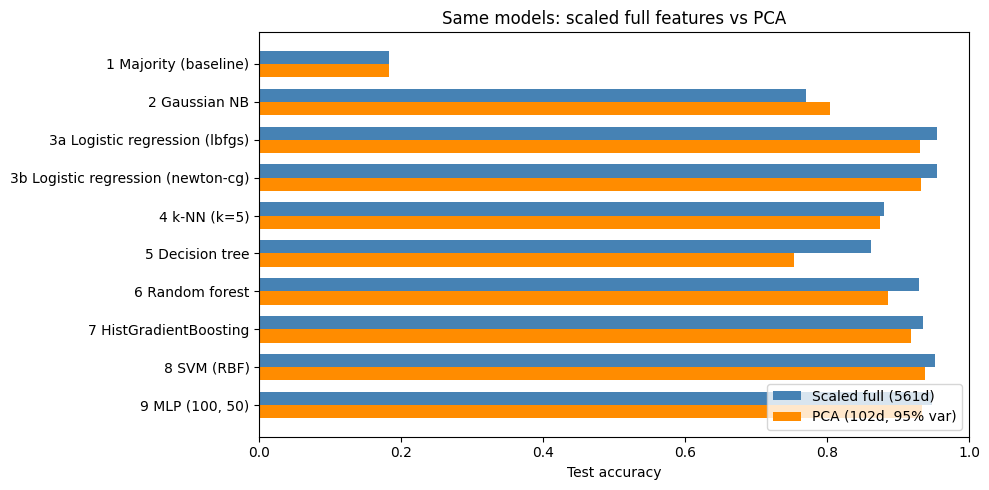

Best on PCA features: 8 SVM (RBF)

                    precision    recall  f1-score   support

           WALKING      0.949     0.968     0.958       496
  WALKING_UPSTAIRS      0.892     0.943     0.916       471
WALKING_DOWNSTAIRS      0.966     0.883     0.923       420
           SITTING      0.931     0.880     0.905       491
          STANDING      0.899     0.940     0.919       532
            LAYING      0.996     1.000     0.998       537

          accuracy                          0.938      2947
         macro avg      0.939     0.936     0.937      2947
      weighted avg      0.939     0.938     0.938      2947



In [4]:
# Requires previous cell: X_train_s, X_test_s, y_train_enc, y_test_enc, run_all_models, MODELS, REP_FULL, results_full

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_s)
X_test_pca = pca.transform(X_test_s)
n_pca = X_train_pca.shape[1]
var_explained = float(np.sum(pca.explained_variance_ratio_))
print(
    f"PCA (fit on train only): {n_pca} components explain {var_explained:.4f} of train variance "
    f"(from 561 scaled features).\n"
)

fig_pca, ax_pca = plt.subplots(figsize=(7, 3))
ax_pca.plot(
    np.arange(1, len(pca.explained_variance_ratio_) + 1),
    np.cumsum(pca.explained_variance_ratio_),
    color="darkgreen",
)
ax_pca.axhline(0.95, color="gray", linestyle="--", label="95% variance target")
ax_pca.set_xlabel("Number of components")
ax_pca.set_ylabel("Cumulative explained variance")
ax_pca.set_title("PCA on scaled training data")
ax_pca.legend()
ax_pca.set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

REP_PCA = f"PCA ({n_pca}d, 95% var)"
results_pca, fitted_pca = run_all_models(X_train_pca, X_test_pca, REP_PCA)

results_compare = pd.concat([results_full, results_pca], ignore_index=True)
display(
    results_compare.sort_values(
        ["representation", "test_accuracy"], ascending=[True, False]
    ).reset_index(drop=True)
)

pivot_acc = results_compare.pivot_table(
    index="model", columns="representation", values="test_accuracy"
)
pivot_f1 = results_compare.pivot_table(
    index="model", columns="representation", values="test_macro_f1"
)
pivot_prec = results_compare.pivot_table(
    index="model", columns="representation", values="test_macro_precision"
)
pivot_rec = results_compare.pivot_table(
    index="model", columns="representation", values="test_macro_recall"
)
display(pivot_acc)
display(pivot_prec)
display(pivot_rec)
display(pivot_f1)

delta = (pivot_acc[REP_PCA] - pivot_acc[REP_FULL]).to_frame("accuracy_delta_PCA_minus_full")
display(delta.sort_values("accuracy_delta_PCA_minus_full", ascending=False))

order = list(MODELS.keys())
x = np.arange(len(order))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(
    x - w / 2,
    pivot_acc[REP_FULL].reindex(order).values,
    w,
    label=REP_FULL,
    color="steelblue",
)
ax.barh(
    x + w / 2,
    pivot_acc[REP_PCA].reindex(order).values,
    w,
    label=REP_PCA,
    color="darkorange",
)
ax.set_yticks(x)
ax.set_yticklabels(order)
ax.set_xlabel("Test accuracy")
ax.set_title("Same models: scaled full features vs PCA")
ax.set_xlim(0, 1)
ax.legend(loc="lower right")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

best_pca_name = results_pca.sort_values("test_accuracy", ascending=False).iloc[0]["model"]
print(f"Best on PCA features: {best_pca_name}\n")
print(
    classification_report(
        y_test_enc,
        fitted_pca[best_pca_name].predict(X_test_pca),
        target_names=target_names,
        digits=3,
    )
)
